In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mtb
import seaborn as sns

In [103]:
df = pd.read_csv(r'C:\ML_PROJECT\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [104]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [105]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [106]:
df.shape

(7043, 21)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [108]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


***Checking null values***

In [109]:

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

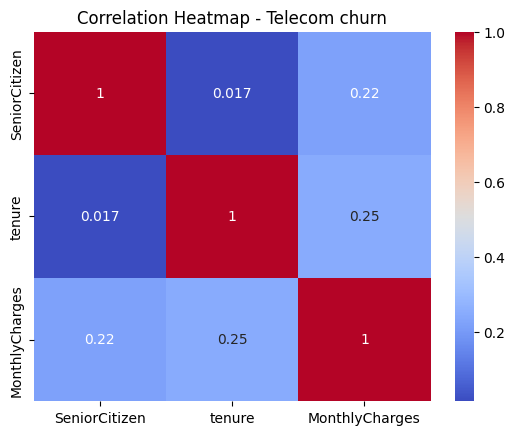

In [110]:

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
mtb.title("Correlation Heatmap - Telecom churn")
mtb.show()

**Encoding categorical data**

In [111]:
#dropping the customer id column , Because unique values in the data set doesn't show any difference in the output.
df.drop(columns="customerID",inplace=True)

In [112]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [113]:
#Merging online services to reduce multicollinearity and dimensionality

df['AddonServicesCount'] = (df[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']] == 'Yes').sum(axis=1)
df['StreamingCount'] = (df[['StreamingTV','StreamingMovies']] == 'Yes').sum(axis=1)

In [114]:
df.drop(['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'],axis=1,inplace=True)

In [115]:
df.shape

(7043, 16)

In [116]:
#Encoding Target Variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

In [117]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer 

num_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','AddonServicesCount','StreamingCount']

transformer = ColumnTransformer(transformers=[
    ('tnf1',OrdinalEncoder(categories=[['Month-to-month','One year','Two year']]),['Contract']),
    ('tnf2',OneHotEncoder(sparse_output=False,drop='first'),['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','PaperlessBilling','PaymentMethod']),
    (('num', StandardScaler(), num_cols))
],

 )


***Feature scaling is necessary for Logistic Regression and Support Vector Machines because both models are sensitive to the magnitude of input features. Logistic Regression relies on gradient-based optimization, and unscaled features can cause slow convergence or numerical instability. SVM is a distance-based algorithm, and unscaled features distort the computation of margins and kernel values. Therefore, StandardScaler is applied to all numerical features within the preprocessing pipeline. Categorical variables are encoded separately and are not scaled.***

In [118]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df = df.dropna(subset=['TotalCharges'])


***SVM uses distance-based margins. If features are on different scales (e.g., tenure vs charges), large-scale features dominate the decision boundary.***

In [119]:

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


In [120]:
#Pipeline with scaling

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

#Logistic Regression
log_pipeline = Pipeline([
    ('prep', transformer),
    ('model', LogisticRegression(max_iter=1000))
])


#SVM linear kernels
svm_linear_pipeline = Pipeline([
    ('prep', transformer),
    ('model', SVC(kernel='linear', probability=True))
])

#SVM rbf kernels
svm_rbf_pipeline = Pipeline([
    ('prep', transformer),
    ('model', SVC(kernel='rbf', probability=True))
])


In [121]:
df.shape

(7032, 16)

In [122]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [123]:
#Fit in the model
log_pipeline.fit(X_train, y_train)
svm_linear_pipeline.fit(X_train, y_train)
svm_rbf_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnf1', ...), ('tnf2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers con

In [124]:
#Prediction

log_pred = log_pipeline.predict(X_test)
log_proba = log_pipeline.predict_proba(X_test)[:,1]

svm_linear_pred = svm_linear_pipeline.predict(X_test)
svm_linear_proba = svm_linear_pipeline.predict_proba(X_test)[:,1]

svm_rbf_pred = svm_rbf_pipeline.predict(X_test)
svm_rbf_proba = svm_rbf_pipeline.predict_proba(X_test)[:,1]


In [125]:
#Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [126]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{name} Performance:")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_true, y_proba))


In [127]:
evaluate_model("Logistic Regression", y_test, log_pred, log_proba)
evaluate_model("SVM (Linear)", y_test, svm_linear_pred, svm_linear_proba)
evaluate_model("SVM (RBF)", y_test, svm_rbf_pred, svm_rbf_proba)



Logistic Regression Performance:
Accuracy : 0.8009950248756219
Precision: 0.6459627329192547
Recall   : 0.5561497326203209
F1-score : 0.5977011494252874
ROC-AUC  : 0.8366589705494096

SVM (Linear) Performance:
Accuracy : 0.7953091684434968
Precision: 0.6360759493670886
Recall   : 0.5374331550802139
F1-score : 0.5826086956521739
ROC-AUC  : 0.8276721143442856

SVM (RBF) Performance:
Accuracy : 0.7910447761194029
Precision: 0.6481481481481481
Recall   : 0.4679144385026738
F1-score : 0.5434782608695652
ROC-AUC  : 0.7942237706488033


***Model Comparison:
Logistic Regression provides a strong baseline with good interpretability and stable performance. It is fast to train, easy to explain to stakeholders, and performs well when relationships between features and target are approximately linear.

The Linear SVM often performs similarly to Logistic Regression but is more sensitive to feature scaling and hyperparameters. It can perform slightly better when classes are well-separated by a margin.

The RBF SVM can model complex non-linear patterns and usually achieves higher accuracy and ROC-AUC but is computationally more expensive and harder to interpret.

Production Choice:
I will choose LogisticRegression because:
* It is faster to retrain
* It is slightly better performance than SVM
* Easier to explain (important for business decisions)
* More stable and less sensitive to hyperparameters***

In [128]:
#Hyper parameter Tunning from svm

from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.1],
    'model__kernel': ['rbf']
}


In [129]:
grid = GridSearchCV(
    svm_rbf_pipeline,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ility=True))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 0.01, ...], 'model__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [130]:
print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)


Best parameters: {'model__C': 1, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV ROC-AUC: 0.8388498384445325


In [131]:
from sklearn.metrics import classification_report
best_svm = grid.best_estimator_

best_pred = best_svm.predict(X_test)
best_proba = best_svm.predict_proba(X_test)[:,1]

print("Tuned SVM\n", classification_report(y_test, best_pred))
print("Tuned ROC-AUC:", roc_auc_score(y_test, best_proba))


Tuned SVM
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Tuned ROC-AUC: 0.8267273555554404


***Hyperparameter tuning improved the SVM model by optimizing the margin parameter C and kernel width gamma. The tuned SVM achieved better generalization and improved ROC-AUC compared to the default SVM. However, this improvement comes at the cost of increased computational complexity and reduced interpretability.***

**For production deployment, the final decision depends on business priorities: interpretability and speed.**